In [1]:
# %matplotlib ipympl
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL, FIGURES_DIR

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import cmap

import scipy.ndimage
import seaborn as sns

from scipy.stats import entropy

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "figure.constrained_layout.use": True,
})

def detect_upstates(
    spikes: nap.TsGroup,
    bin_size = 0.01,
    percentile = 80,
    merge_thr = 0.1,
    short_thr = 0.04,
    long_thr = 2,
    time_units='s'
    ) -> nap.IntervalSet:
    x = spikes.count(bin_size=bin_size, time_units=time_units).sum(axis=1)
    x = x / bin_size
    x = x.smooth(std=2 * bin_size, time_units=time_units)
    thr = np.percentile(x, q=percentile)

    up_states = x.threshold(thr, method='above').time_support
    up_states = up_states.merge_close_intervals(threshold=merge_thr, time_units=time_units)
    up_states = up_states.drop_short_intervals(threshold=short_thr, time_units=time_units)
    up_states = up_states.drop_long_intervals(threshold=long_thr, time_units=time_units)
    return up_states, thr

cyclic_cmap = cmap.Colormap('cmocean:phase').to_mpl()
seq_cmap = cmap.Colormap('cmasher:tropical').to_mpl()

In [2]:
mouse_id        = "107b"

sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction  = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")
hd_units        = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "hd_units.npz")
session         = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")

nrem            = sleep[sleep['state'] == 'nrem'].intersect(session[session['state'] == 'homecage'])

# compute HD preferred angle
tcs = nap.compute_tuning_curves(hd_units, head_direction, bins=24, fs=1000, feature_names=['hd'])
tcs.values = scipy.ndimage.gaussian_filter1d(tcs.values, sigma=1, axis=1, mode="wrap")
pref_angle = tcs.idxmax(dim='hd').to_numpy().squeeze()

# order unit ids
order = np.argsort(pref_angle)
hd_uids = np.array(hd_units.keys())[order]

order = np.argsort(turn_units['turn_index'].values)
turn_uids = np.array(turn_units.keys())[order]

# detect up states
spikes = hd_units.restrict(nrem)
up_states, thr = detect_upstates(spikes)

In [9]:
data_dir        = INTERIM_DIR / "decoded" / mouse_id

idx = 52

ep = nrem[idx]

norm_entropy = nap.load_file(data_dir / f"{mouse_id}_{idx}_entropy.npz")
p_feature = nap.load_file(data_dir / f"{mouse_id}_{idx}_position_posterior.npz")
p_max = nap.load_file(data_dir / f"{mouse_id}_{idx}_position.npz")

p_feature = p_feature.bin_average(0.005)
p_max = p_max.bin_average(0.005)
norm_entropy = norm_entropy.bin_average(0.005)

hd_spikes = hd_units.restrict(ep)
up_eps = up_states.intersect(ep)

valid_eps = norm_entropy.threshold(0.5, method='below').time_support
valid_eps = valid_eps.merge_close_intervals(threshold=50, time_units='ms')
valid_eps = valid_eps.drop_short_intervals(threshold=20, time_units='ms')
valid_eps = valid_eps.drop_long_intervals(threshold=2, time_units='s')

print(f"NREM epoch: {ep.start.item():.2f} s - {ep.end.item():.2f} s")
print(f"Valid epoch length: {valid_eps.tot_length():.2f} s")

NREM epoch: 23119.00 s - 23190.00 s
Valid epoch length: 2.82 s


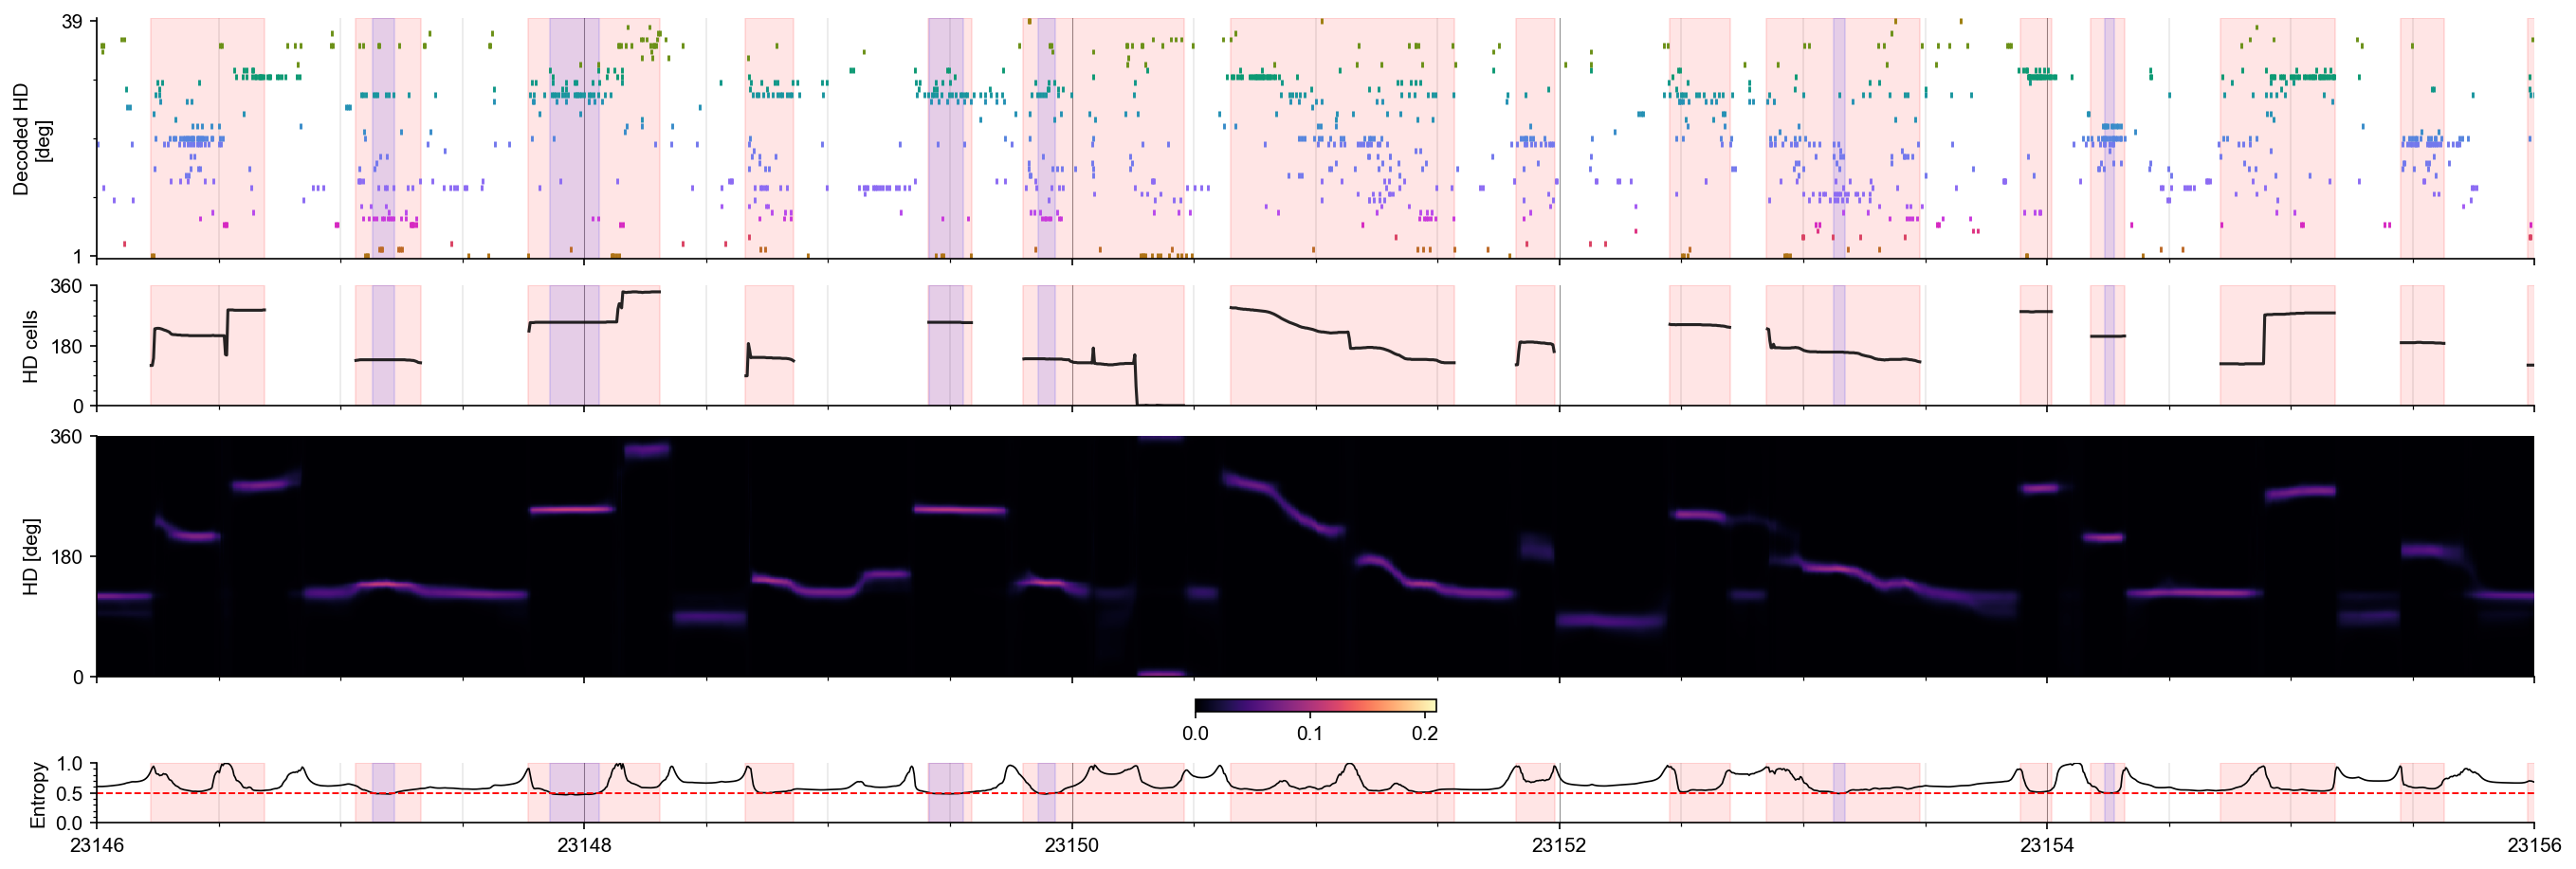

In [14]:
f, ax = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(18, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1, 2, 0.5]})

# HD cells raster
for row, uid in enumerate(hd_uids, start=1):
    ax[0].eventplot(
        hd_spikes[uid].index,
        lineoffsets=row,
        linelengths=0.9,
        linewidths=1.4,
        colors=[cyclic_cmap(pref_angle[uid].item() / 360)],
        alpha=1,
    )

# Decoded HD
for ep in up_eps:
    ax[1].plot(p_max.restrict(ep), color='0.05', alpha=0.9, linewidth=1.5)

mesh = ax[2].pcolormesh(
    p_feature.t,
    p_feature.columns.to_numpy(dtype=float),
    p_feature.d.T,
    shading='auto',
    cmap='magma',
    vmin=0,
)

f.colorbar(mesh, ax=ax[2], orientation='horizontal', aspect=20, fraction=0.05)

ax[3].plot(p_max.t, norm_entropy, linewidth=0.8, color='k')
ax[3].axhline(0.5, linewidth=0.9, color='r', linestyle='--')

for a in ax:
    a.set_axisbelow(True)
    a.grid(axis='x', which='major', color='0.86', linewidth=0.6)
    a.spines[["top", "right"]].set_visible(False)

ax[0].set_ylabel("Decoded HD\n[deg]")
ax[0].set_ylim(0.5, len(hd_uids) + 0.5)
ax[0].set_yticks([1, len(hd_uids)])

ax[1].set_ylabel("HD cells")
ax[1].set_ylim((0, 360))
ax[1].set_yticks([0, 180, 360])


ax[2].set_ylabel("HD [deg]")
ax[2].set_ylim((0, 360))
ax[2].set_yticks([0, 180, 360])

ax[3].set_ylabel("Entropy")
ax[3].set_ylim((0, 1))
ax[3].set_yticks((0, 0.5, 1))

ax[0].set_xlim((23146, 23156))

for a in ax:
    if a == ax[2]:
        continue
    a.minorticks_on()
    a.grid(axis='x', which='major', color='0.1', alpha=0.5, linewidth=0.5)
    a.grid(axis='x', which='minor', color='0.3', alpha=0.5, linewidth=0.2)
    for start, end in up_eps.values:
        a.axvspan(start, end, color='r', alpha=0.1,)
    for start, end in valid_eps.values:
        a.axvspan(start, end, color='b', alpha=0.1,)

# plt.savefig(FIGURES_DIR / "snapshots" / "nrem_upstate00.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "snapshots" / "nrem_upstate00.png", format='png', bbox_inches='tight')
plt.show()